<a href="https://colab.research.google.com/github/AllenSWDB/TReND-CaMinA/blob/main/notebooks/Kenya26/03_04-Wed1toThu2-AllenTutorial/solutions/Project_8_Classifying-Transgenic-Lines_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exploring the neural coding & behavioral dimensions of different transgenic lines

---

### Background

The **Allen Brain Observatory** is a large-scale public dataset of two-photon calcium imaging (optical physiology) collected from head-fixed mice passively viewing visual stimuli. A key feature of the dataset is its use of **transgenic Cre lines**: each mouse expresses a fluorescent calcium indicator (typically GCaMP6f) under the control of a Cre recombinase whose expression is restricted to a specific neuronal cell type (e.g., layer 2/3 excitatory neurons, layer 5 excitatory neurons, SST+ interneurons). All animals share the same inbred background strain (**C57BL/6J**), differ only in which Cre allele they carry.

During each imaging session (~60 min), mice are free to run on a treadmill and are tracked by an eye-tracking camera, yielding continuous **running speed** and **pupil size / gaze position** time series alongside the neural fluorescence data. How these behavioral variables relate to neural activity has been extensively quantified in *de Vries 2020* and consolidated into a cell metrics table for future analysis. This tutorial will utilize this table & pre-computed behavioral variables to create an project space independent of the full dataset, which is a behemoth of nearly 1,400 experiments!!

### Motivation

The cre lines used in this study were designed to investigate different populations of neurons, so we should expect differences in visual coding properties. We will investigate this using a pre-computed metrics table to expand our understanding in the various dimensions explored in these experiments. Namely, stimulus driven activity & how this activity relates to the behavior of the animal. To quantify this, decoding will be utilized to determine which transgenic lines can be classified from each other and with which features. If this is successful, we can further ask, can we use behavior by itself to classify cre lines from each other. Because all Cre lines were derived from the same background strain, the naïve expectation is that behavioral phenotypes should be essentially identical across lines.

### Project Goals

1. **Identify neural coding dimensions** that vary across cortical layers, cortical areas, and transgenic lines
2. **Characterize running and pupil behavior** across all transgenic lines in the Allen Brain Observatory optical physiology dataset.
3. **Train and evaluate linear classifiers** (SVM, LDA, Logistic Regression) to decode Cre-line identity from neural coding metrics & behavioral features alone, using stratified cross-validation.
4. **Validate against a shuffle-label null distribution** to rigorously test whether decoding accuracy exceeds chance.
5. **Identify the most discriminative features** and the most confusable pairs of transgenic lines.


In [ ]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restxart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()

In [1]:
%matplotlib inline
## Import Required Libraries
#Base
import os
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as st

#Core
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

#Plot
import matplotlib.pyplot as plt
import seaborn as sns

#Live dangerously
import warnings
warnings.filterwarnings('ignore')

#Data
DATA_DIR = Path("/data/visual_coding_ophys")
MANIFEST_PATH = DATA_DIR / "brain_observatory_manifest.json"
NWB_DIR = DATA_DIR / "ophys_experiment_data"

session_types = ['three_session_A','three_session_B','three_session_C','three_session_C2']
# Initialize the cache. Setting `manifest_file` to the local manifest avoids any download.
boc = BrainObservatoryCache(manifest_file=str(MANIFEST_PATH))

# Get high-level metadata tables
containers_df = pd.DataFrame(boc.get_experiment_containers())
containers_df = containers_df.rename(columns={'id':'experiment_container_id'}).set_index('experiment_container_id')
experiments_df = pd.DataFrame(boc.get_ophys_experiments())
experiments_df = experiments_df[experiments_df['session_type'].isin(session_types)]
uniq_container_ids = experiments_df['experiment_container_id'].unique()
containers_df = containers_df.loc[uniq_container_ids]
experiments_df.set_index('id', inplace=True)

print(f"{len(containers_df)} experiment containers, {len(experiments_df)} ophys experiments")
experiments_df.head()

456 experiment containers, 1368 ophys experiments


,imaging_depth,targeted_structure,cre_line,reporter_line,acquisition_age_days,experiment_container_id,session_type,donor_name,specimen_name,fail_eye_tracking
id,,,,,,,,,,
649409874,175,VISpm,Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),100,646959440,three_session_A,350249,Vip-IRES-Cre;Ai148-350249,False
663488086,175,VISl,Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),124,662358769,three_session_B,361636,Slc17a7-IRES2-Cre;Camk2a-tTA;Ai93-361636,False
604328043,375,VISrl,Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),104,604328040,three_session_A,325932,Slc17a7-IRES2-Cre;Camk2a-tTA;Ai93-325932,False
577225417,275,VISl,Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),105,575772104,three_session_C2,296710,Vip-IRES-Cre;Ai148-296710,False
556353209,375,VISam,Rbp4-Cre_KL100,Ai93(TITL-GCaMP6f),101,555327033,three_session_A,271750,Rbp4-Cre;Camk2a-tTA;Ai93-271750,True


# 1. How do visual responses of excitatory cells differ across cortical depths using transgenic lines?

In [2]:
#Read in pandas dataframe with pre-computed metrics for all cells
metrics_all = pd.read_csv("metrics_clean_2025.csv",index_col=0)

uniq_cre_lines = np.unique(metrics_all['tld1_name'])
uniq_areas = np.unique(metrics_all['area'])
nCre_lines = len(uniq_cre_lines)
nAreas = len(uniq_areas)
print(f'Unique areas recorded: {uniq_areas}')
print(f"Metrics table shape: {metrics_all.shape[0]} cells across {nCre_lines} cre lines and {nAreas} areas with {metrics_all.shape[1]} columns !! Woah that is too much to look at! ")
metrics_all.head()

Unique areas recorded: ['VISal' 'VISam' 'VISl' 'VISp' 'VISpm' 'VISrl']
Metrics table shape: 59610 cells across 12 cre lines and 6 areas with 110 columns !! Woah that is too much to look at! 


,cell_specimen_id,lifetime_sparseness_nm3,responsive_nm3,reliability_nm3,peak_frame_nm3,lifetime_sparseness_nm1a,responsive_nm1a,reliability_nm1a,peak_frame_nm1a,lifetime_sparseness_nm1b,...,cv_lsn,responsive_nmall,run_stat_dg,responsive_rundg,run_corr_mean,run_corr_A_lw,run_corr_B_lw,run_corr_C_lw,responsive_run,dg_all_RidgeRegress_CC
0,570928778,0.979543,False,0.014272,1026.0,0.967212,False,0.016819,583.0,0.985687,...,5.975376,True,NaN,False,NaN,-0.001078,-0.018117,0.039354,False,0.083038
1,570928986,0.967574,False,0.011196,361.0,0.978374,True,0.344332,365.0,0.991609,...,NaN,True,-0.551957,False,NaN,0.001142,0.078896,NaN,False,0.278657
2,570929244,0.972431,False,0.019493,804.0,0.970074,False,0.016020,370.0,0.984001,...,NaN,True,NaN,False,NaN,0.016949,0.113203,NaN,False,0.257520
3,570929249,0.984766,False,0.011741,696.0,0.993494,True,0.213434,145.0,0.984524,...,NaN,True,NaN,False,NaN,0.004977,0.067388,NaN,False,0.294201
4,570928981,0.968906,True,0.046999,161.0,0.961156,False,0.024980,329.0,NaN,...,NaN,True,2.937988,False,NaN,0.066659,NaN,NaN,False,0.407533


In [3]:
## Subsample the metrics table to focus on a subset of cre lines and one area (VISp) for this analysis
# Below are the 8 lines we will focus on for this analysis, which have more specific expression patterns in different cortical layers and cell types
# Excluding 'Emx1-IRES-Cre', 'Slc17a7-IRES2-Cre' because they are pan-excitatory lines and we want to focus on the more specific lines that target particular cortical layers and cell types for this analysis.
#
# What do all of these transgenic lines (tld1_name) even mean?
#       Look here -> https://observatory.brain-map.org/visualcoding/transgenic
#
# Don't panic! Most computational neuroscientists (myself included) don't understand the full details of all of these transgenic lines, how they are created, etc,
# but the key point is that they allow us to target different subsets of cells across the brain, which is very useful for understanding how diverse cell types / brain areas contribute to visual processing and behavior.

cre_lines_of_interest = [
                        'Cux2-CreERT2',     #GCaMP6f expression is enriched in cortical layers 2, 3 and 4, among other areas
                        'Rorb-IRES2-Cre',   #GCaMP6f expression is predominantly in excitatory neurons in cortical layer 4 (dense) and layers 5/6 (sparse), among other areas
                        'Scnn1a-Tg3-Cre',   #GCaMP6f is predominantly expressed in excitatory neurons in cortical layer 4, among other areas
                        'Nr5a1-Cre',        #GCaMP6f is predominantly expressed in excitatory neurons in cortical layer 4 , among other areas
                        'Fezf2-CreER',      #GCaMP6f is strongly expressed in cortical layer 5 and some layer 6 excitatory neurons, among other areas
                        'Tlx3-Cre_PL56',    #GCaMP6f is strongly expressed in cortical layer 5 and some layer 6 excitatory neurons, among other areas
                        'Rbp4-Cre_KL100',   #GCaMP6f is predominantly expressed in excitatory neurons in cortical layer 5, among other areas
                        'Ntsr1-Cre_GN220',  #GCaMP6f expression is specific to cortical layer 6 neurons
                        ]

#Pandas query allows us to subset the metrics_all dataframe to only include rows where area is VISp and tld1_name is in our list of cre lines of interest
subsample_criteria = f"(area == 'VISp') & (tld1_name.isin(@cre_lines_of_interest))"
metrics_VISp = metrics_all.query(subsample_criteria)
print(f"After subsampling to focus on VISp and {len(cre_lines_of_interest)} cre lines of interest labeling specific populations of excitatory cells, we *only* have {metrics_VISp.shape[0]} cells")

After subsampling to focus on VISp and 8 cre lines of interest labeling specific populations of excitatory cells, we *only* have 12369 cells


In [4]:
## Since we have so many pre-computed metrics, here is a brief summary of some of the most important columns
# More details can be obtained from the platform paper  (de Vries et al., 2020) & from the TAs
#
# _dg suffix means the metric was computed for the drifting grating stimulus responses
# _sg suffix means the metric was computed for the static grating stimulus responses
# _nm3 suffix means the metric was computed for the natural movie 3 stimulus responses
# _nm1 suffix means the metric was computed for the natural movie 1 stimulus responses
# _ns suffix means the metric was computed for natural scene stimulus responses
#
# DRIFTING GRATINGS METRICS:
# 'pref_ori_dg':            preferred orientation for drifting gratings
# 'pref_tf_dg':             preferred temporal frequency for drifting gratings
# 'num_pref_trials_dg':     number of trials at the preferred orientation for drifting gratings
# 'responsive_dg':          whether the cell is responsive to drifting gratings
# 'g_osi_dg':               orientation selectivity index for drifting gratings
# 'g_dsi_dg':               direction selectivity index for drifting gratings
# 'tfdi_dg':                temporal frequency direction index for drifting gratings
# 'reliability_dg':         defined by the percentage of significant responses to repeated presentations of drifting gratings
# 'lifetime_sparseness_dg': lifetime sparseness of the cell's response to drifting gratings
# 'cv_dg':                  coefficient of variation of the cell's response to drifting gratings
#
# RUNNING METRICS:
# 'run_pval_dg':            p-value for running modulation for drifting gratings
# 'run_resp_dg':            running response for drifting gratings
# 'run_mod_dg':             running modulation for drifting gratings
# 'responsive_rundg':       whether the cell is responsive to drifting gratings during running
# 'run_corr_mean':          mean correlation of the cell's response to running speed across all sessions
# 'run_corr_A_lw':          mean correlation of the cell's response to running speed during session A (drifting gratings & natural movies)
# 'run_corr_B_lw':          mean correlation of the cell's response to running speed during session B (static gratings & natural scenes)
# 'run_corr_C_lw':          mean correlation of the cell's response to running speed during session C (locally sparse noise & natural movies)
# 'responsive_run':         whether the cell is responsive to running


In [5]:
# Drifting gratings is a commonly used visual stimulus in systems neuroscience, so let's start by looking at some of these metrics for different transgenic lines.
# 24 columns is much more manageable! 
metrics_dg = metrics_VISp[['cell_specimen_id','experiment_container_id','tld1_name','area','imaging_depth','depth_range',
                          'pref_ori_dg','pref_tf_dg','num_pref_trials_dg','responsive_dg','g_osi_dg',
                          'g_dsi_dg','tfdi_dg','reliability_dg','lifetime_sparseness_dg','cv_dg',
                          'run_pval_dg','run_resp_dg','run_mod_dg','responsive_rundg','run_corr_mean',
                          'run_corr_A_lw','run_corr_B_lw','run_corr_C_lw','responsive_run']]
metrics_dg = metrics_dg.set_index('cell_specimen_id')
metrics_dg.head()

,experiment_container_id,tld1_name,area,imaging_depth,depth_range,pref_ori_dg,pref_tf_dg,num_pref_trials_dg,responsive_dg,g_osi_dg,...,cv_dg,run_pval_dg,run_resp_dg,run_mod_dg,responsive_rundg,run_corr_mean,run_corr_A_lw,run_corr_B_lw,run_corr_C_lw,responsive_run
cell_specimen_id,,,,,,,,,,,,,,,,,,,,,
729434558,701412138,Cux2-CreERT2,VISp,175.0,100,270.0,4.0,3.0,False,0.294051,...,2.241300,0.471995,0.001508,-0.354194,False,0.089185,-0.010712,0.181654,0.096612,True
729434571,701412138,Cux2-CreERT2,VISp,175.0,100,0.0,8.0,15.0,True,0.942779,...,2.130336,0.205036,0.063385,0.280422,False,-0.000861,0.008890,-0.011007,-0.000467,True
729434545,701412138,Cux2-CreERT2,VISp,175.0,100,180.0,1.0,10.0,True,0.696913,...,2.622545,0.738069,0.011059,0.190675,False,0.046287,-0.004225,0.127382,0.015705,True
729434504,701412138,Cux2-CreERT2,VISp,175.0,100,225.0,1.0,12.0,True,0.571656,...,2.291576,0.077720,0.014170,0.482701,False,-0.002180,0.008019,NaN,-0.012378,True
729435081,701412138,Cux2-CreERT2,VISp,175.0,100,315.0,1.0,4.0,True,0.210836,...,2.393500,NaN,NaN,NaN,False,-0.004678,-0.005666,0.003561,-0.011929,True


In [8]:
## How many cells have pre-computed metrics for across different cortical layers?
# Ignoring for a moment the complexity of different transgenic lines, let's look at how many cells we have with pre-computed metrics across different cortical layers (depth_range column) in VISp.
#
# 100: L2/3
# 200: L4
# 300: L5
# 500: L6
depth_ranges = np.array([100, 200, 300, 500])

#To make this more interpretable, let's map the depth_range values to their corresponding layer labels
layer_labels = ['L2/3', 'L4', 'L5', 'L6']
metrics_dg['layer'] = metrics_dg['depth_range'].map(dict(zip(depth_ranges, layer_labels)))

#If you're interested in decoding layer & area labels, you can also create a new column that combines area and layer information
metrics_dg['area_layer'] = metrics_dg['area'] + '_' + metrics_dg['layer']

#How many cells do we have with pre-computed metrics across different layers?
print("Number of cells with pre-computed metrics across different layers in VISp:")
metrics_dg['layer'].value_counts().sort_index()


Number of cells with pre-computed metrics across different layers in VISp:


L2/3    2419
L4      7331
L5      2046
L6       573
Name: layer, dtype: int64

In [9]:
#Calculate the proportion of units that are responsive to drifting gratings for each tld1 line
#Normalize by the total number of units recorded for each line to get a proportion
proportion_units_responsive_dg = metrics_dg[["layer", "responsive_dg"]].groupby("layer").sum()/metrics_dg[["layer", "responsive_dg"]].groupby("layer").count()
proportion_units_responsive_dg

,responsive_dg
layer,
L2/3,0.452131
L4,0.549740
L5,0.568858
L6,0.596059


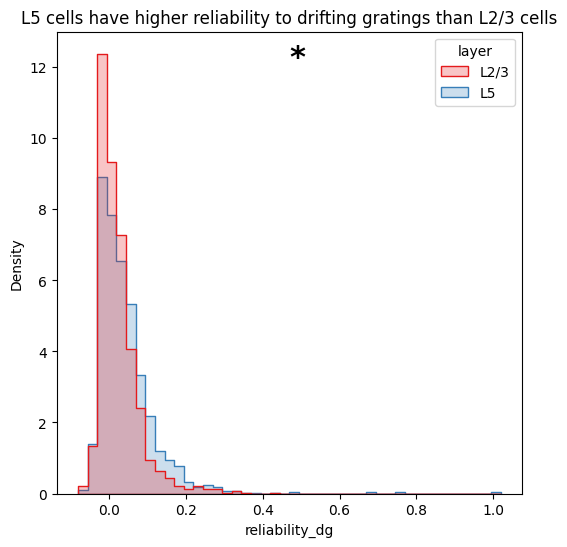

In [15]:
# Looking at this table, we can see that deeper cortical layers have a higher proportion of cells that are responsive to drifting gratings than superficial L2/3.
# Let's plot the distribution of reliability (quantified as the % of significant responses) to drifting gratings of these 2 depths

def plot_metric_distributions(metric_col, group_col='layer', binwidth=None, group_order=layer_labels, title=None, test_significance=False):

    cmap = sns.color_palette("Set1", n_colors=len(group_order))
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title(title)
    sns.histplot(data=metrics_dg[metrics_dg[group_col].isin(group_order)], x=metric_col, hue=group_col,palette=cmap,hue_order=group_order, multiple='layer',element='step',stat='density',common_norm=False, binwidth=binwidth, ax=ax)

    #Check significance between 2 distributions
    if (test_significance) and (len(group_order) == 2):
        distr_g1 = metrics_dg.loc[metrics_dg[group_col] == group_order[0],metric_col].values
        distr_g2 =  metrics_dg.loc[metrics_dg[group_col] == group_order[1],metric_col].values
        res = st.mannwhitneyu(distr_g1,distr_g2,nan_policy='omit')

        if res.pvalue < 0.05:
            ax.text(0.5,0.925,'*',transform=ax.transAxes,fontsize=22,fontweight='bold')

title_str = "L5 cells have higher reliability to drifting gratings than L2/3 cells"
plot_metric_distributions('reliability_dg', group_order=['L2/3','L5'],title=title_str,binwidth=0.025, test_significance=True)


In [11]:
# PLOTTING EXERCISE: We found that L5 cells have a higher proportion of responsive cells to drifting gratings than L2/3 cells, and that L5 cells also have higher reliability to drifting gratings than L2/3 cells.
# What do the other 2 layers look like? Does this pattern hold across all layers? Can you find 2 layers where the opposite is true? 
# (i.e. one line has a higher proportion of responsive cells, but lower reliability than the other line)
mean_reliability = metrics_dg.groupby('layer')['reliability_dg'].mean()
mean_reliability

layer
L2/3    0.022595
L4      0.033249
L5      0.044218
L6      0.024761
Name: reliability_dg, dtype: float64

Text(0, 0.5, 'Mean reliability to drifting gratings')

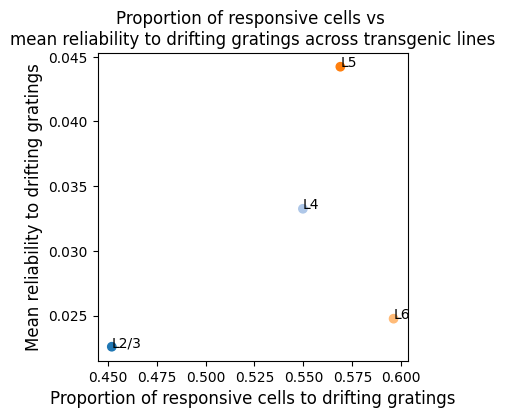

In [12]:
xys = []; labels = []; colors=[]
for ii, (layer, mean_relia) in enumerate(mean_reliability.items()):
    xys.append((proportion_units_responsive_dg.loc[layer].values[0], mean_relia))
    labels.append(layer)

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_title("Proportion of responsive cells vs \nmean reliability to drifting gratings across transgenic lines")
ax.scatter(*zip(*xys),color=sns.color_palette("tab20", n_colors=len(xys)))
for i, label in enumerate(labels):
    ax.text(xys[i][0], xys[i][1], label)
ax.set_xlabel("Proportion of responsive cells to drifting gratings",fontsize=12)
ax.set_ylabel("Mean reliability to drifting gratings",fontsize=12)


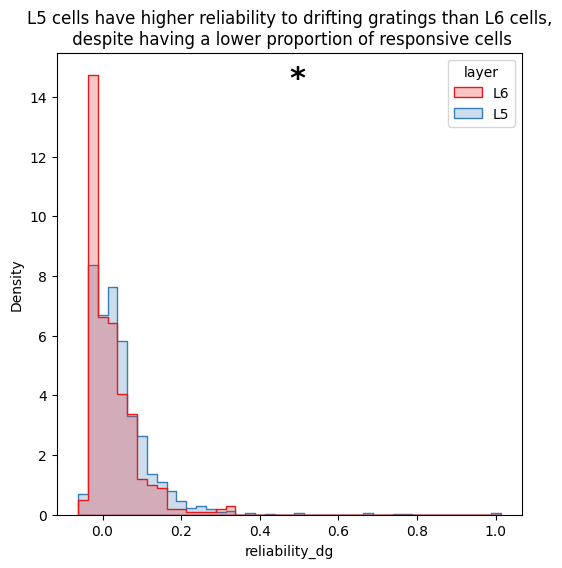

In [16]:
title_str = "L5 cells have higher reliability to drifting gratings than L6 cells,\n despite having a lower proportion of responsive cells"
plot_metric_distributions('reliability_dg', group_col='layer',group_order=['L6','L5'],title=title_str,binwidth=0.025, test_significance=True)


In [ ]:
## Exercise: As a corrollary to reliability, what does the sparseness of the responses to drifting gratings look like across different cortical depths? 
# Sparseness is a measure of how selective a neuron is to different stimuli. A neuron that responds strongly to only a few stimuli will have a lifetime sparseness close to 1, 
# whereas a neuron that responds broadly to many stimuli will  have a lower lifetime sparseness.
mean_sparseness = metrics_dg.groupby('layer')['lifetime_sparseness_dg'].mean()
mean_sparseness

layer
L2/3    0.579835
L4      0.657717
L5      0.665100
L6      0.539231
Name: lifetime_sparseness_dg, dtype: float64

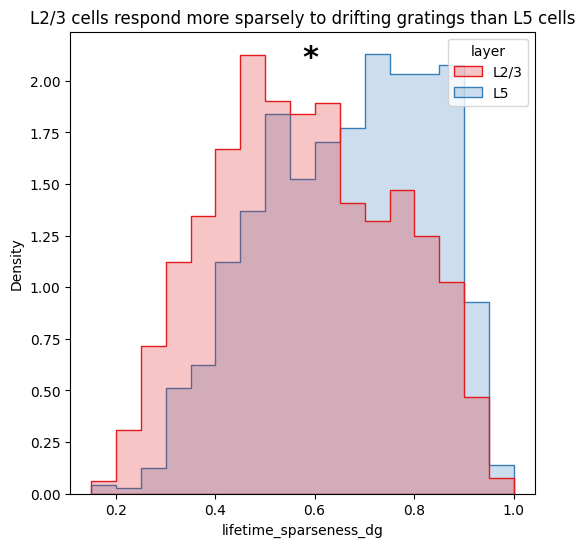

In [ ]:
title_str = 'L2/3 cells respond more sparsely to drifting gratings than L5 cells'

plot_metric_distributions('lifetime_sparseness_dg', group_col='layer',group_order=['L2/3','L5'],title=title_str,binwidth=0.05, test_significance=True)


In [19]:
## EXERCISE: Using the same pandas code as above, Calculate the proportion of units that are responsive to locomotion in general ("responsive_run") & locomotion during drifting_gratings ("responsive_rundg") for each layer
# Which layer has the highest proportion of responsive cells to locomotion? 
proportion_units_responsive_run = metrics_dg[["layer", "responsive_rundg","responsive_run"]].groupby("layer").sum()/metrics_dg[["layer", "responsive_rundg","responsive_run"]].groupby("layer").count()
proportion_units_responsive_run.sort_values("responsive_run", ascending=False,inplace=True)
proportion_units_responsive_run

,responsive_rundg,responsive_run
layer,,
L2/3,0.063663,0.797024
L4,0.053472,0.568681
L6,0.047120,0.401396
L5,0.081134,0.300587


In [21]:
mean_runmod_by_layer = metrics_dg.groupby('layer')['run_mod_dg'].mean()
mean_runmod_by_layer

layer
L2/3    0.191953
L4      0.309626
L5      0.422801
L6      0.100417
Name: run_mod_dg, dtype: float64

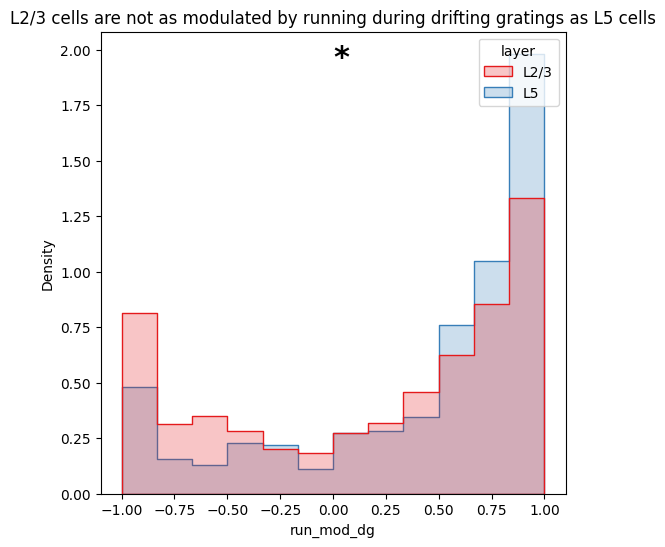

In [22]:
## Different cortical depths have different proportions of cells that are modulated by running, which is interesting to think 
# about in the context of how the neurons embedding in a neural circuit contribute to visual processing during behavior. 

# PLOTTING EXERCISE
# Let's plot the distribution of running modulation during drifting gratings ("run_mod_dg") for superficial (L2/3) vs deep (L5) layers, 
# since we found that they have different proportions of responsive cells to drifting gratings and different reliability to drifting gratings, which might be related to how modulated they are by running during drifting gratings.
# 

title_str = 'L2/3 cells are not as modulated by running during drifting gratings as L5 cells'
plot_metric_distributions('run_mod_dg', group_col='layer',group_order=['L2/3','L5'],title=title_str, test_significance=True)

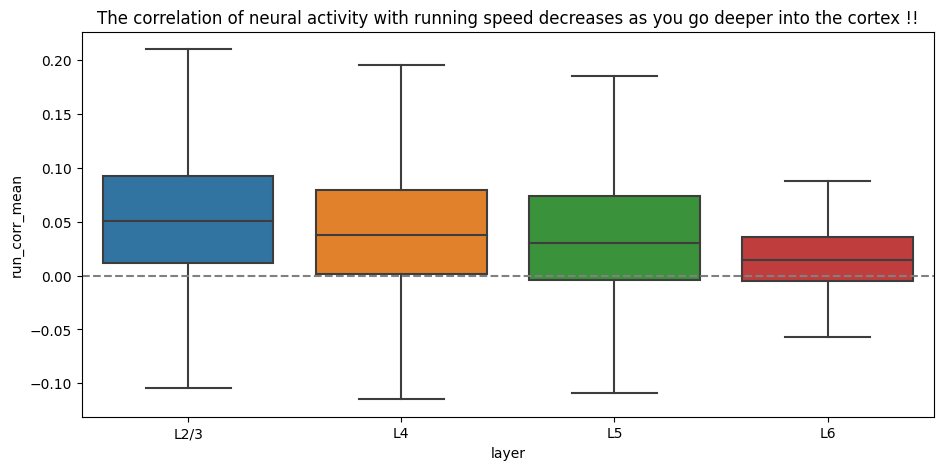

In [23]:
# CONTINUING EXERCISES
# Explore how different metrics vary across different cortical depths or even brain regions
# -> -> Metrics like direction selectivity ('g_dsi_dg'), orientation selectivity ('g_osi_dg'), lifetime sparseness ('lifetime_sparseness_dg'), coefficient of variation ('cv_dg') are all interesting metrics to explore across different layers and brain areas.
# Try to leverage Pandas & Seaborn functionalities to explore these relationships and visualize them in a way that is easy to interpret.
# Perhaps start with "run_corr_mean", or look at Fig 6. of the platform paper (de Vries et al., 2020) to get inspiration 

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_title("The correlation of neural activity with running speed decreases as you go deeper into the cortex !!")
sns.boxplot(data=metrics_dg, y='run_corr_mean', x='layer',order=layer_labels, ax=ax,showfliers=False)
ax.axhline(0, color='gray', linestyle='--')

# If you are brave, you can even look at different stimuli (e.g. static gratings, natural movies, etc) and see how these relationships change across different stimulus types.

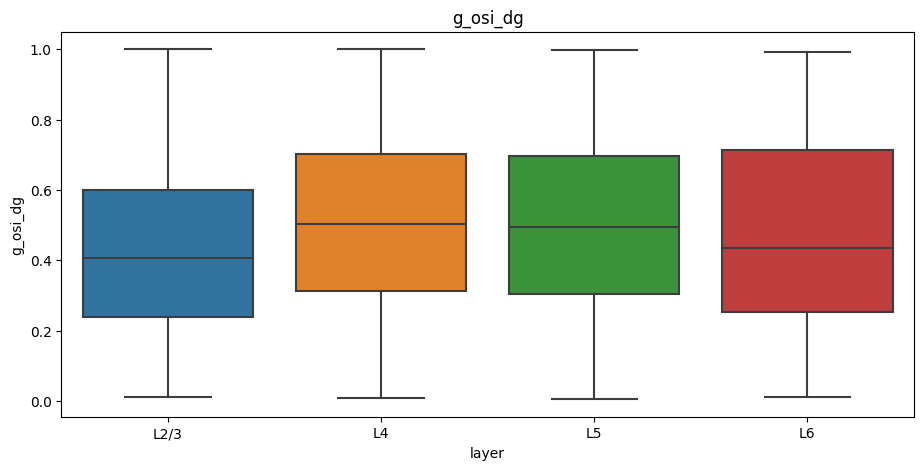

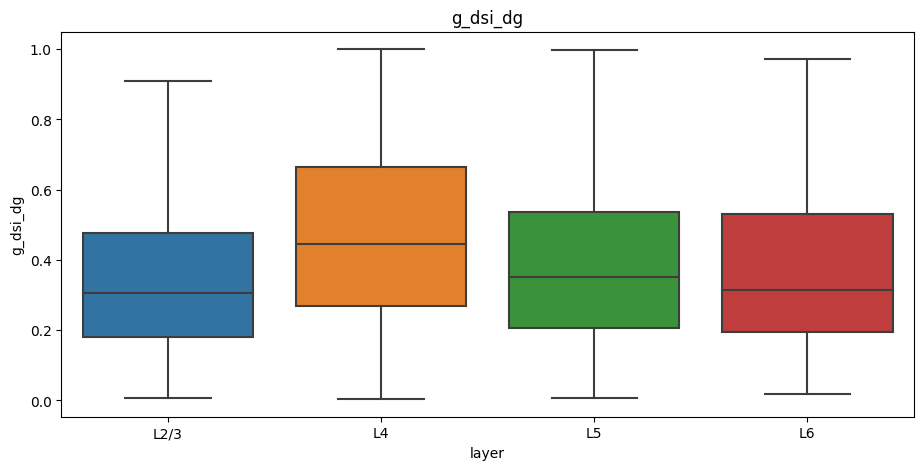

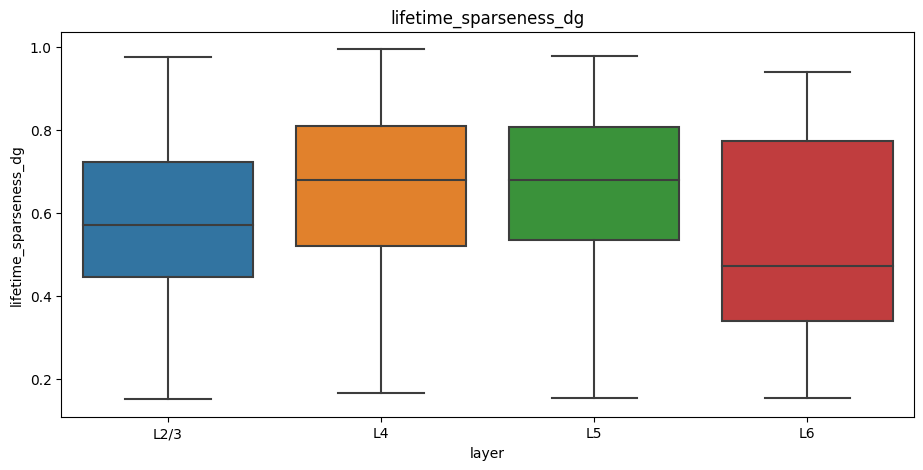

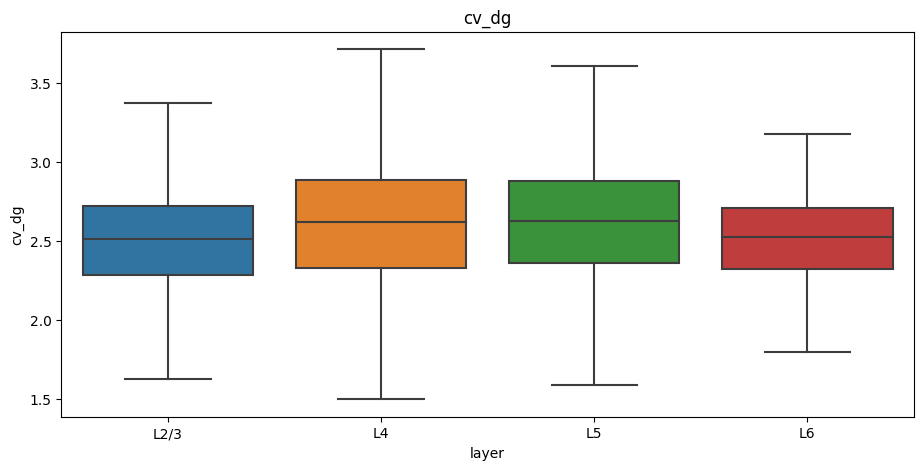

In [18]:
for metric in ['g_osi_dg', 'g_dsi_dg','lifetime_sparseness_dg','cv_dg']:
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.set_title(f"{metric}")
    sns.boxplot(data=metrics_dg, y=metric, x='layer',order=layer_labels, ax=ax,showfliers=False)

# 2. Are these neural coding dimensions predictive of cortical depth?

In [24]:
## Project motivation & possible directions
# Above we were looking at metrics over all cells recorded in V1 in a subset of excitatory cre lines,
# but we can also look at different metrics on a single experiment level and ask if that is predictive
# of the type of transgenic animal the recording was taken from.
# We will have to decide what features our classifier will use and what decoding technique to try
# I will highlight a simple attempt using drifing grating metrics below, but feel free to get creative and try different approaches!


In [25]:
#These are some classification libraries for doing classification in Python, but feel free to use any other libraries you are comfortable with!
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [26]:
min_units = 10
summary_per_experiment = []
#Loop over unique container ids (all imaging sessions for 1 imaging plane; i.e. some cells might have been recorded across multiple sessions)
for exp_c_id in np.unique(metrics_dg['experiment_container_id']):
    exp_data = metrics_dg[metrics_dg['experiment_container_id'] == exp_c_id]
    n_units = len(exp_data)

    if n_units < min_units:
        continue

    #Drifting grating metrics
    summary_per_experiment.append({

        #Metadata about the experiment
        'layer': exp_data['layer'].values[0],
        'experiment_container_id': exp_c_id,
        'area': containers_df.at[exp_c_id, 'targeted_structure'],
        'cre_line': containers_df.at[exp_c_id, 'cre_line'],
        'imaging_depth': containers_df.at[exp_c_id, 'imaging_depth'],
        'n_units': n_units,

        # Proportion of responsive cells to drifting gratings for this experiment
        'resp_dg_prop': exp_data['responsive_dg'].sum() / n_units,
        
        #Just calculate the mean of each metric across all cells in the experiment
        'reliability': np.nanmean(exp_data['reliability_dg']),
        'sparseness': np.nanmean(exp_data['lifetime_sparseness_dg']),
        'osi': np.nanmean(exp_data['g_osi_dg']),
        'dsi': np.nanmean(exp_data['g_dsi_dg']),
        'cv': np.nanmean(exp_data['cv_dg']),

        #But we could also calculate the mean of each metric across only the responsive cells in the experiment 
        'reliability_resp': np.nanmean(exp_data.loc[exp_data['responsive_dg'] == True,'reliability_dg']),
        'sparseness_resp': np.nanmean(exp_data.loc[exp_data['responsive_dg'] == True,'lifetime_sparseness_dg']),
        'osi_resp': np.nanmean(exp_data.loc[exp_data['responsive_dg'] == True,'g_osi_dg']),
        'dsi_resp': np.nanmean(exp_data.loc[exp_data['responsive_dg'] == True,'g_dsi_dg']),
        'cv_resp': np.nanmean(exp_data.loc[exp_data['responsive_dg'] == True,'cv_dg']),


    })

#You can create a pandas dataframe like this
summary_df = pd.DataFrame(summary_per_experiment)
summary_df.head()

,layer,experiment_container_id,area,cre_line,imaging_depth,n_units,resp_dg_prop,reliability,sparseness,osi,dsi,cv,reliability_resp,sparseness_resp,osi_resp,dsi_resp,cv_resp
0,L4,511498742,VISp,Scnn1a-Tg3-Cre,350,295,0.186441,0.020943,0.653092,0.440677,0.421564,2.902522,0.033889,0.748872,0.533600,0.535730,2.837692
1,L2/3,511507650,VISp,Cux2-CreERT2,175,305,0.304918,0.025858,0.603263,0.454182,0.360118,2.568504,0.029583,0.665051,0.544622,0.371969,2.426546
2,L4,511507811,VISp,Scnn1a-Tg3-Cre,350,237,0.345992,0.015853,0.649969,0.449191,0.410395,2.677702,0.017867,0.677680,0.461681,0.407033,2.621425
3,L2/3,511509529,VISp,Cux2-CreERT2,175,295,0.430508,0.023997,0.570498,0.401835,0.326548,2.365904,0.028387,0.634142,0.458937,0.355471,2.307694
4,L2/3,511510650,VISp,Cux2-CreERT2,175,243,0.366255,0.017712,0.570660,0.459303,0.311160,2.421033,0.026555,0.624552,0.520965,0.303428,2.304429


In [27]:
# --- Build feature matrix and labels ---
features = ['resp_dg_prop', 
            'reliability','sparseness', 'osi', 'dsi','cv',
            ]

target = 'layer'

# Drop rows with NaNs in any predictor or the label
clf_df = summary_df[features + [target]].dropna().copy()
X = clf_df[features].to_numpy()
y = clf_df[target].to_numpy()

print(f"Samples: {len(clf_df)}, features: {X.shape[1]}, classes: {np.unique(y).size}")

# How many data points do we have for each transgenic line?
summary_df['layer'].value_counts()


Samples: 64, features: 6, classes: 4


L4      33
L5      17
L2/3     8
L6       6
Name: layer, dtype: int64

Using 5-fold stratified CV (smallest class = 6)

Fold accuracies: [0.923 0.923 0.923 0.923 0.583]
Mean accuracy:   0.855 +/- 0.136
Chance (1/n_classes): 0.250

Classification report (out-of-fold):
              precision    recall  f1-score   support

        L2/3       0.70      0.88      0.78         8
          L4       0.94      0.88      0.91        33
          L5       1.00      0.82      0.90        17
          L6       0.56      0.83      0.67         6

    accuracy                           0.86        64
   macro avg       0.80      0.85      0.81        64
weighted avg       0.89      0.86      0.87        64



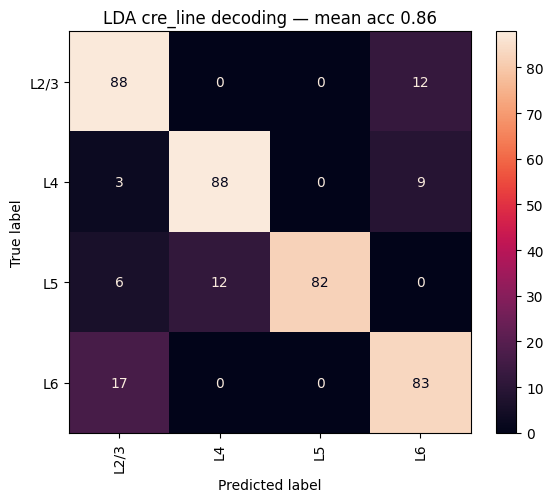

In [28]:
# Stratified k-fold CV 
# n_splits cannot exceed the smallest class size
min_class = clf_df[target].value_counts().min()
n_splits = int(min(5, min_class))
print(f"Using {n_splits}-fold stratified CV (smallest class = {min_class})")
n_classes = np.unique(y).size

#Define a simple pipeline that scales the features and then applies LDA for classification
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('SVM (linear)', SVC(kernel='linear', class_weight='balanced')),
    # ('LogReg', LogisticRegression(max_iter=5000, class_weight='balanced')),
])

# Create the StratifiedKFold object and compute cross-validated accuracy scores
skf = StratifiedKFold(n_splits=n_splits)

# Feed these objects into the cross_val_score function to get out-of-fold accuracy scores for each fold, 
# and then compute the mean and standard deviation of these scores across folds to get an estimate of how well our classifier is performing on unseen data.
cv_scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
print(f"\nFold accuracies: {np.round(cv_scores, 3)}")
print(f"Mean accuracy:   {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print(f"Chance (1/n_classes): {1.0 / np.unique(y).size:.3f}")

# Out-of-fold predictions for a confusion matrix / classification report
y_pred = cross_val_predict(pipe, X, y, cv=skf)
print("\nClassification report (out-of-fold):")
print(classification_report(y, y_pred, zero_division=0))

labels = np.unique(y)
cm = confusion_matrix(y, y_pred, labels=labels, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm*100, display_labels=labels).plot(ax=ax, cmap='rocket',include_values=True,values_format='.0f',
                                                       xticks_rotation=90, colorbar=True)
ax.set_title(f"LDA cre_line decoding — mean acc {cv_scores.mean():.2f}")
plt.tight_layout()
plt.show()


In [29]:
## EXERCISE: Can we think of a simple way to test if our decoding accuracy is significantly above chance by creating a shuffle distribution?
# The simplest way to do this is to shuffle the labels (layer) across experiments and re-run the same CV procedure. 
# This will break any real relationship between the features and the labels, and give us a null distribution of accuracies we can compare our real accuracy against.
n_shuffles_simple = 100
rng_simple = np.random.default_rng(0)

null_accs = np.zeros(n_shuffles_simple)
null_cms = np.zeros((n_shuffles_simple, len(labels), len(labels)), dtype=float)

for s in range(n_shuffles_simple):
    y_shuf = rng_simple.permutation(y)
    null_accs[s] = cross_val_score(pipe, X, y_shuf, cv=skf, scoring='accuracy').mean()

    y_pred_shuf = cross_val_predict(pipe, X, y_shuf, cv=skf)
    cm_s = confusion_matrix(y_shuf, y_pred_shuf, labels=labels)
    null_cms[s] = cm_s / cm_s.sum(axis=1, keepdims=True)  # row-normalized

real_acc = cv_scores.mean()
p_val = (null_accs >= real_acc).mean()  # one-sided

null_mean_cm = null_cms.mean(axis=0)
null_p95_cm = np.quantile(null_cms, 0.95, axis=0)
p_cells = (null_cms >= cm[None, :, :]).mean(axis=0)
sig_cells = p_cells < 0.05

print(f"Real CV accuracy:        {real_acc:.3f}")
print(f"Shuffle null mean:       {null_accs.mean():.3f} +/- {null_accs.std():.3f}")
print(f"Shuffle null 95th pct:   {np.quantile(null_accs, 0.95):.3f}")
print(f"Naive 1/n_classes:       {1.0 / np.unique(y).size:.3f}")
print(f"p (real > null):         {p_val:.4f}  ({n_shuffles_simple} shuffles)")
print(f"Cells significant (p<0.05, uncorrected): {sig_cells.sum()} / {sig_cells.size}  "
      f"(diagonal: {np.diag(sig_cells).sum()}/{len(labels)})")


Real CV accuracy:        0.855
Shuffle null mean:       0.256 +/- 0.071
Shuffle null 95th pct:   0.378
Naive 1/n_classes:       0.250
p (real > null):         0.0000  (100 shuffles)
Cells significant (p<0.05, uncorrected): 4 / 16  (diagonal: 4/4)


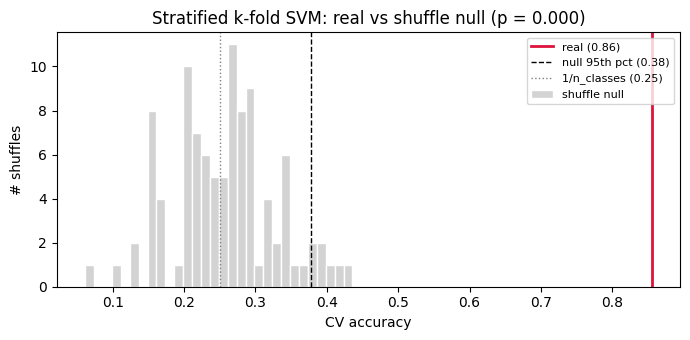

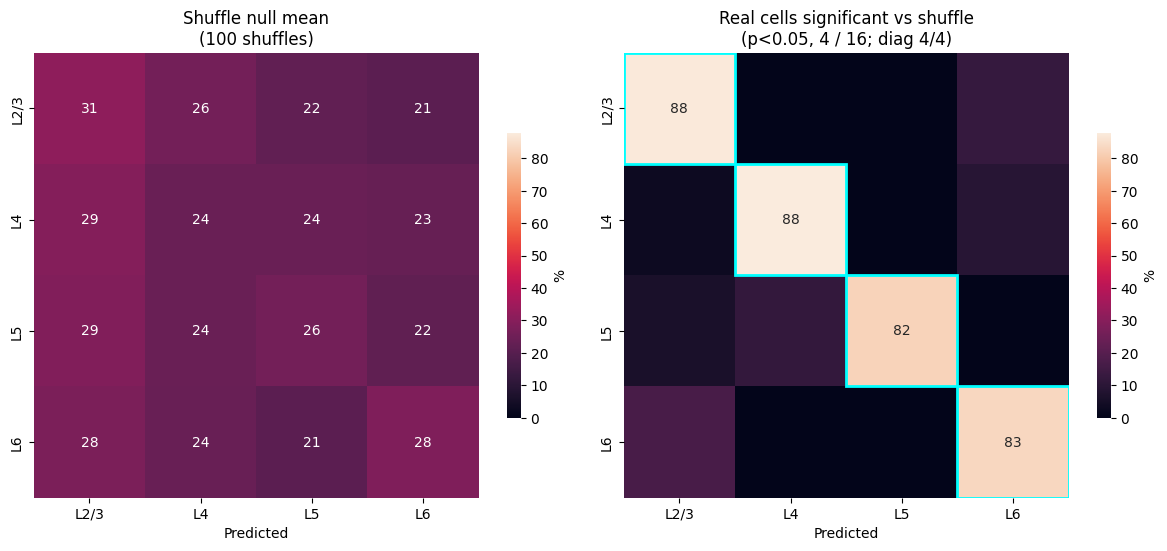

In [30]:

# 1) Accuracy null distribution
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(null_accs, bins=30, color='lightgray', edgecolor='white', label='shuffle null')
ax.axvline(real_acc, color='crimson', lw=2, label=f'real ({real_acc:.2f})')
ax.axvline(np.quantile(null_accs, 0.95), color='k', ls='--', lw=1,
           label=f'null 95th pct ({np.quantile(null_accs, 0.95):.2f})')
ax.axvline(1 / np.unique(y).size, color='gray', ls=':', lw=1,
           label=f'1/n_classes ({1/np.unique(y).size:.2f})')
ax.set_xlabel('CV accuracy'); ax.set_ylabel('# shuffles')
ax.set_title(f'Stratified k-fold SVM: real vs shuffle null (p = {p_val:.3f})')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

# 2) Heatmap of the shuffle confusion-matrix distribution
vmax = float(max((cm * 100).max(), (null_p95_cm * 100).max()))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(null_mean_cm * 100, annot=True, fmt=".0f", cmap='rocket', square=True,
            xticklabels=labels, yticklabels=labels,
            vmin=0, vmax=vmax, ax=axes[0],cbar_kws={'label': '%','shrink': 0.5})
axes[0].set_title(f"Shuffle null mean\n({n_shuffles_simple} shuffles)")
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('')

# Real cm with significance markers
annot = np.where(sig_cells, np.round(cm * 100).astype(int).astype(str), "")
sns.heatmap(cm * 100, annot=annot, fmt="", cmap='rocket', square=True,
            xticklabels=labels, yticklabels=labels,
            vmin=0, vmax=vmax, ax=axes[1],cbar_kws={'label': '%','shrink': 0.5})
for (i, j), s_ in np.ndenumerate(sig_cells):
    if s_:
        axes[1].add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                        edgecolor='cyan', lw=2))
axes[1].set_title(f"Real cells significant vs shuffle\n(p<0.05, "
                  f"{sig_cells.sum()} / {sig_cells.size}; "
                  f"diag {np.diag(sig_cells).sum()}/{len(labels)})")
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('')

plt.tight_layout(); plt.show()


Feature importance from linear SVM coefficients (|coef| averaged across class pairs):


,feature,mean_abs_coef
0,dsi,1.019487
1,sparseness,0.903327
2,osi,0.749258
3,resp_dg_prop,0.648538
4,cv,0.580583
5,reliability,0.401611



Feature importance from permutation importance (drop in accuracy when shuffled):


,feature,perm_importance_mean,perm_importance_std
0,dsi,0.411875,0.057856
1,sparseness,0.232187,0.046141
2,resp_dg_prop,0.127812,0.040947
3,osi,0.124375,0.035762
4,cv,0.075625,0.036358
5,reliability,0.046562,0.028383


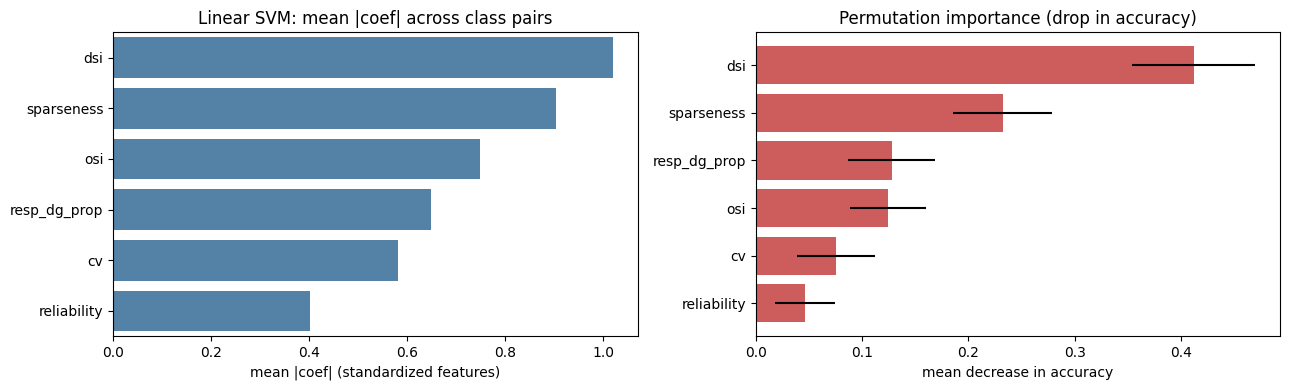

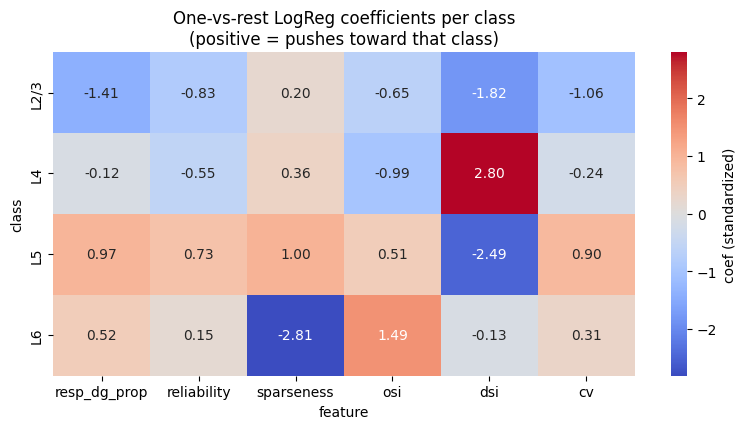

In [31]:
## EXERCISE: Which features are most predictive in our decoder?
# For a *linear* model (linear SVM, LDA, LogReg), the magnitude of the fitted coefficient
# for each (standardized) feature is a direct measure of how strongly it contributes to the
# decision boundary. A more general-purpose approach that works for any pipeline is
# permutation importance: shuffle one feature at a time, see how much CV accuracy drops.

from sklearn.inspection import permutation_importance

# ---- 1) Linear SVM coefficients (per class-pair) -----------------------------
# Fit the pipeline on ALL data once so we can inspect coefficients.
# Coefficients live in standardized-feature space because of the StandardScaler step,
# which is what we want so the magnitudes are directly comparable across features.
pipe.fit(X, y)
svm = pipe.named_steps['SVM (linear)']

# For multi-class one-vs-one SVC, coef_ has shape (n_classes*(n_classes-1)/2, n_features).
# A simple summary across class-pairs is the mean absolute coefficient per feature.
coef = svm.coef_                                # (n_pairs, n_features)
mean_abs_coef = np.mean(np.abs(coef), axis=0)   # (n_features,)

coef_importance = (
    pd.DataFrame({'feature': features, 'mean_abs_coef': mean_abs_coef})
    .sort_values('mean_abs_coef', ascending=False)
    .reset_index(drop=True)
)
print("Feature importance from linear SVM coefficients (|coef| averaged across class pairs):")
display(coef_importance)

# ---- 2) Permutation importance (model-agnostic) ------------------------------
# Shuffles each feature n_repeats times and measures the drop in accuracy.
# Works for any estimator (linear or not).
perm = permutation_importance(
    pipe, X, y,
    n_repeats=50,
    random_state=0,
    scoring='accuracy',
    n_jobs=-1,
)
perm_importance = (
    pd.DataFrame({
        'feature': features,
        'perm_importance_mean': perm.importances_mean,
        'perm_importance_std':  perm.importances_std,
    })
    .sort_values('perm_importance_mean', ascending=False)
    .reset_index(drop=True)
)
print("\nFeature importance from permutation importance (drop in accuracy when shuffled):")
display(perm_importance)

# ---- 3) Plot both side-by-side -----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order_coef = coef_importance['feature'].tolist()
sns.barplot(data=coef_importance, x='mean_abs_coef', y='feature',
            order=order_coef, ax=axes[0], color='steelblue')
axes[0].set_title('Linear SVM: mean |coef| across class pairs')
axes[0].set_xlabel('mean |coef| (standardized features)')
axes[0].set_ylabel('')

order_perm = perm_importance['feature'].tolist()
axes[1].barh(order_perm, perm_importance['perm_importance_mean'],
             xerr=perm_importance['perm_importance_std'], color='indianred')
axes[1].invert_yaxis()
axes[1].set_title('Permutation importance (drop in accuracy)')
axes[1].set_xlabel('mean decrease in accuracy')

plt.tight_layout()
plt.show()

# ---- 4) Bonus: per-class coefficient heatmap (which feature drives which layer?) ----
# One-vs-one SVC pairs aren't per-class, so refit with LogReg (one-vs-rest) to get
# an interpretable (n_classes, n_features) coefficient matrix.
pipe_ovr = Pipeline([
    ('scale', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=5000, class_weight='balanced',
                                  multi_class='ovr')),
])
pipe_ovr.fit(X, y)
ovr_coef = pipe_ovr.named_steps['logreg'].coef_      # (n_classes, n_features)
ovr_classes = pipe_ovr.named_steps['logreg'].classes_

coef_heatmap_df = pd.DataFrame(ovr_coef, index=ovr_classes, columns=features)

plt.figure(figsize=(8, 0.6 * len(ovr_classes) + 2))
sns.heatmap(coef_heatmap_df, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'coef (standardized)'})
plt.title('One-vs-rest LogReg coefficients per class\n(positive = pushes toward that class)')
plt.xlabel('feature'); plt.ylabel('class')
plt.tight_layout(); plt.show()


## MORE PROJECT IDEAS & DIRECTIONS OF EXPLORATION
1. Choose different features to train your classifier on and see if you can decode cortical layers with different sets of features.
- Try features that relate neural activity to locomotion. Is this enough to classify cortical layers? ['resp_run_prop', 'resp_rundg_prop','run_mod', 'run_corr', 'run_mod_resp', 'run_corr_resp'] 
2. Instead of decoding cortical depth within a particular area, can you decode brain area or cell-type (by adding 'Vip-IRES-Cre' & 'Sst-IRES-Cre' back to the metrics table)?
- Combinatorially, this can get pretty complex, but you can start by trying to decode VISp, VISl, VISal, & VISam across all depths first, before splitting by depth.
3. Do other stimulus types (e.g. static gratings, natural movies, etc) have different predictive ability across layers or areas?

# 3. Is behavior itself predictive of transgenic line?
Ok, so clearly neural activity is different in our different transgenic lines / cortical layers. That is why we did experiments on these animals in the first place! Is it possible though that our genetic manipulations also altered the behavior of the animal? Can we *just* look at the behavior of an animal to say something about which transgenic line it is a part of? Remember, all of these lines are created from the same background animal, C57. So, the answer should be no? 

In [32]:
#Let's look at the running behavior of 2 cre lines, both of which target layer 5 excitatory neurons in cortex! 
cre_list = ['Tlx3-Cre_PL56','Fezf2-CreER']
experiments_sub_df = experiments_df.loc[(experiments_df['cre_line'].isin(cre_list)), ['experiment_container_id', 'targeted_structure','imaging_depth', 'cre_line','reporter_line', 'session_type']]
experiments_sub_df.head(10)

,experiment_container_id,targeted_structure,imaging_depth,cre_line,reporter_line,session_type
id,,,,,,
647593956,643667453,VISl,375,Tlx3-Cre_PL56,Ai148(TIT2L-GC6f-ICL-tTA2),three_session_C2
645689073,643667453,VISl,375,Tlx3-Cre_PL56,Ai148(TIT2L-GC6f-ICL-tTA2),three_session_A
613599793,609198028,VISl,375,Fezf2-CreER,Ai148(TIT2L-GC6f-ICL-tTA2),three_session_C2
638262098,637669268,VISp,375,Tlx3-Cre_PL56,Ai148(TIT2L-GC6f-ICL-tTA2),three_session_C2
636930038,616886391,VISp,400,Fezf2-CreER,Ai148(TIT2L-GC6f-ICL-tTA2),three_session_B
652737678,650510286,VISl,375,Fezf2-CreER,Ai148(TIT2L-GC6f-ICL-tTA2),three_session_A
675478137,674802081,VISp,390,Fezf2-CreER,Ai148(TIT2L-GC6f-ICL-tTA2),three_session_C2
657016267,657016265,VISp,375,Tlx3-Cre_PL56,Ai148(TIT2L-GC6f-ICL-tTA2),three_session_A
638262535,637671552,VISp,375,Tlx3-Cre_PL56,Ai148(TIT2L-GC6f-ICL-tTA2),three_session_C2


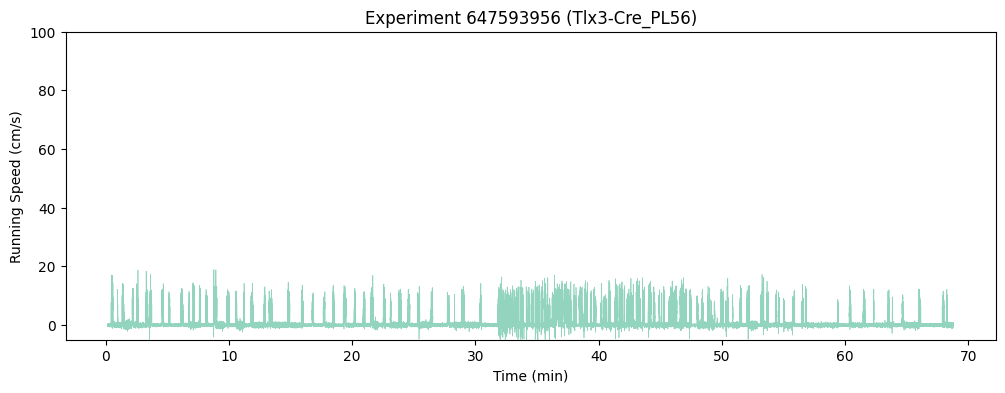

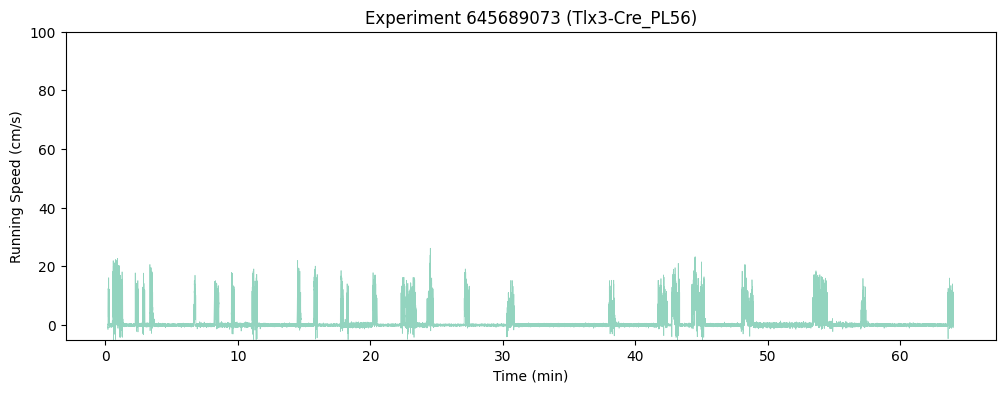

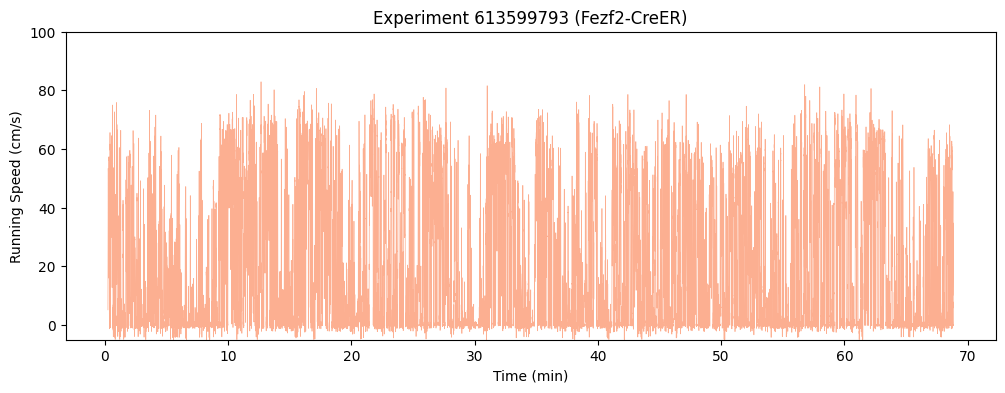

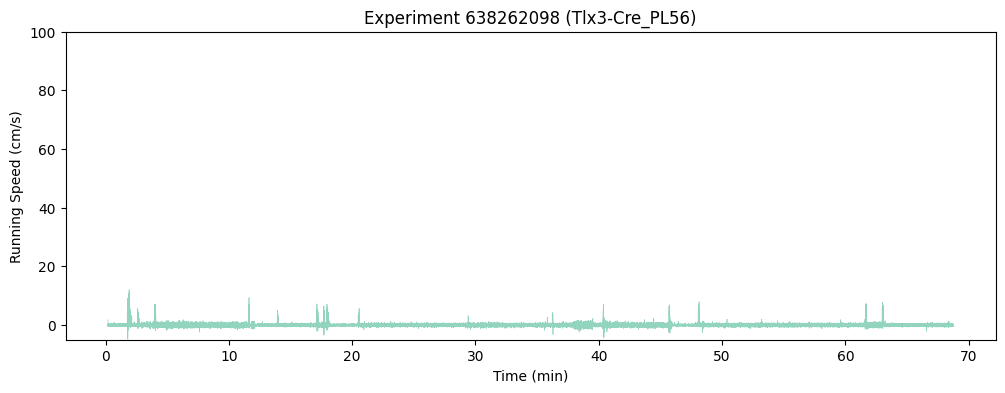

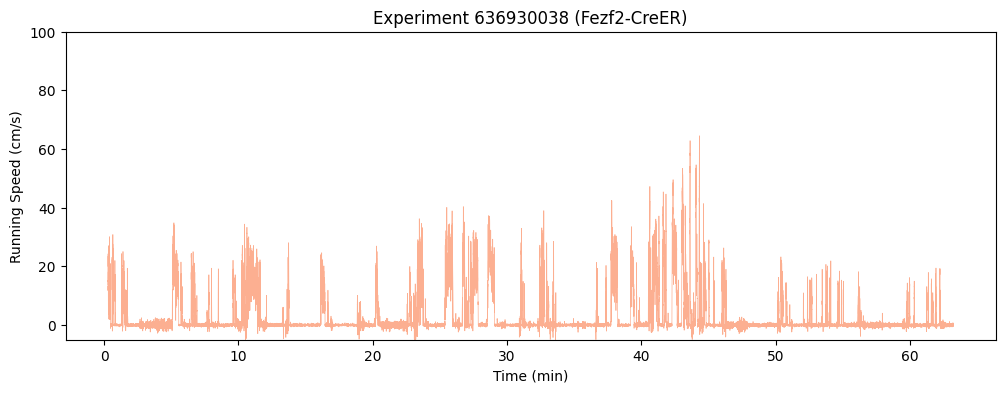

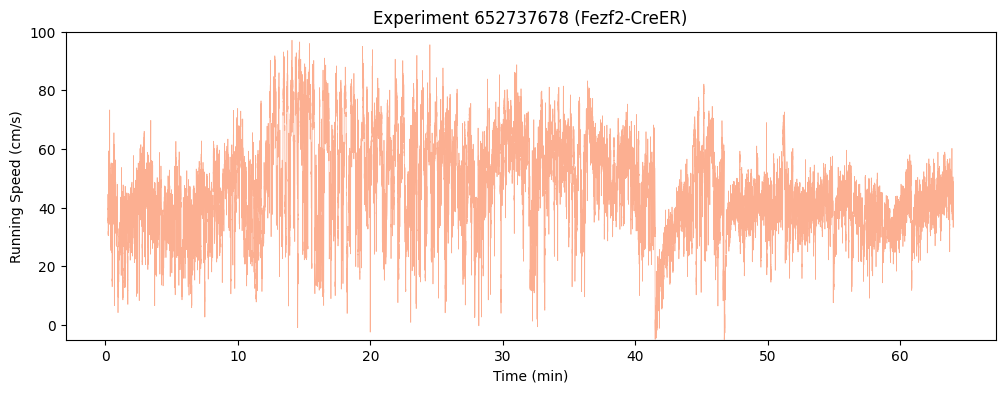

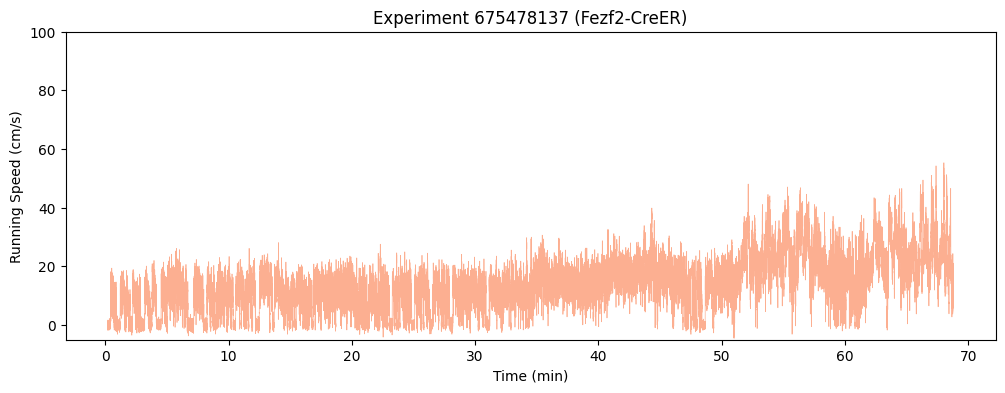

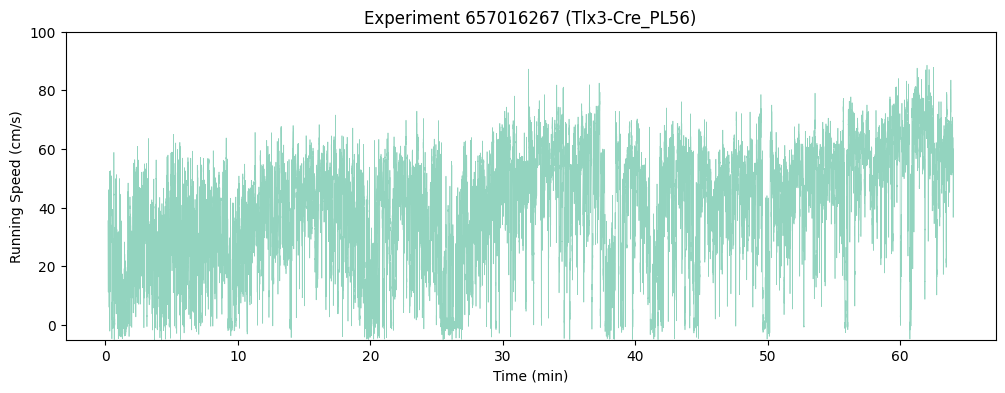

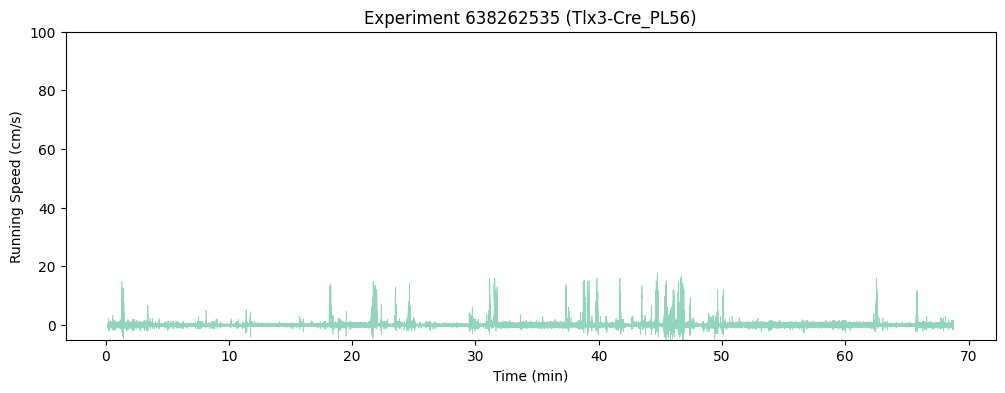

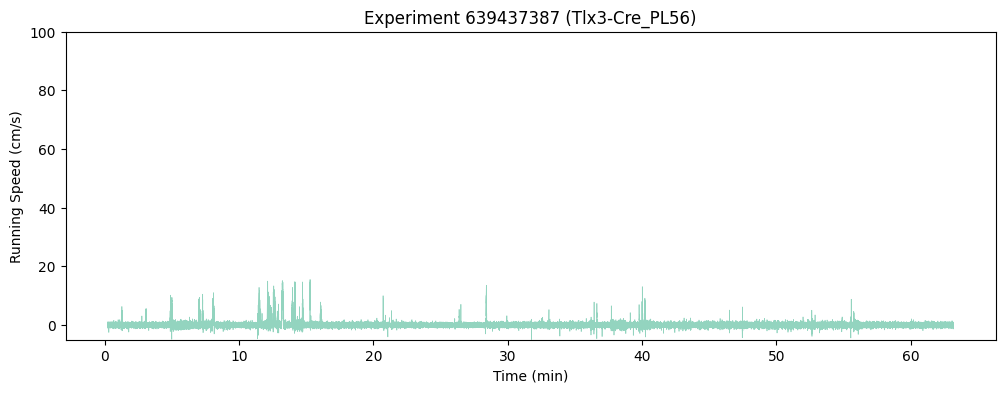

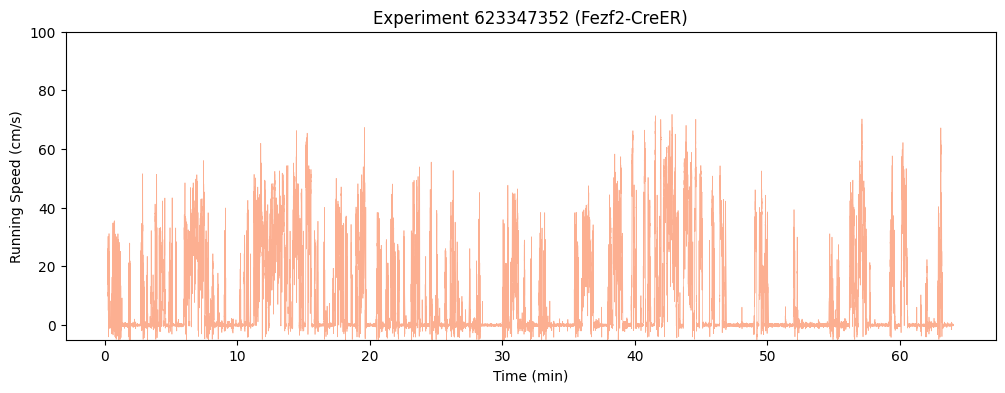

In [33]:
## EXERCISE: Plot the running speed of a few example sessions, and compare across the two cre lines. Do you see any differences?
# What features could you calculate from the running speed time series, and how would you compare across the two cre lines?
# Use this code snippet to get the running speed time series for a given experiment,
#   ds = boc.get_ophys_experiment_data(exp_id)
#   speed, ts = ds.get_running_speed()

num_plots_per_creline = np.zeros((2,))
cmap2 = sns.color_palette("Set2", n_colors=2)
plot_num = 5
for exp_id, row in experiments_sub_df.iterrows():
    cre_line = row['cre_line']
    idx = cre_list.index(cre_line)
    
    if num_plots_per_creline[idx] > plot_num:
        continue

    num_plots_per_creline[idx] += 1
    ds = boc.get_ophys_experiment_data(exp_id)
    speed, ts = ds.get_running_speed()
    
    #Get valid speed values (non-NaN)
    valid = np.isfinite(speed) & np.isfinite(ts) & (speed >= -5) & (speed <= 100)

    speed = speed[valid]
    ts = ts[valid]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(ts/60, speed,lw=0.5,color=cmap2[idx],alpha=0.7)
    ax.set_title(f"Experiment {exp_id} ({cre_line})")
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Running Speed (cm/s)")
    ax.set_ylim(-5, 100)
    if np.all(num_plots_per_creline >= plot_num):
        break

In [34]:
## Exercise: Compute some simple statistics from the running speed time series, such as mean speed, variance of speed, fraction of time spent running. Do you see any differences in these features across the two cre lines?
running_stats = []
for exp_id, row in experiments_sub_df.iterrows():
    cre_line = row['cre_line']

    ds = boc.get_ophys_experiment_data(exp_id)
    speed, ts = ds.get_running_speed()
    valid = np.isfinite(speed) & np.isfinite(ts) & (speed >= -5) & (speed <= 100)
    speed = speed[valid]
    ts = ts[valid]

    running_stats.append({
        'experiment_id': exp_id,
        'cre_line': cre_line,
        'mean_speed': np.mean(speed),
        'var_speed': np.var(speed),
        'fraction_time_running': np.mean(speed > 2.0)
    })
running_stats_df = pd.DataFrame(running_stats)
running_stats_df.groupby('cre_line')[['mean_speed', 'var_speed', 'fraction_time_running']].mean()

,mean_speed,var_speed,fraction_time_running
cre_line,,,
Fezf2-CreER,25.957776,231.016338,0.758303
Tlx3-Cre_PL56,10.394841,87.468090,0.335932


Counts per cre line:


Tlx3-Cre_PL56    27
Fezf2-CreER      27
Name: cre_line, dtype: int64

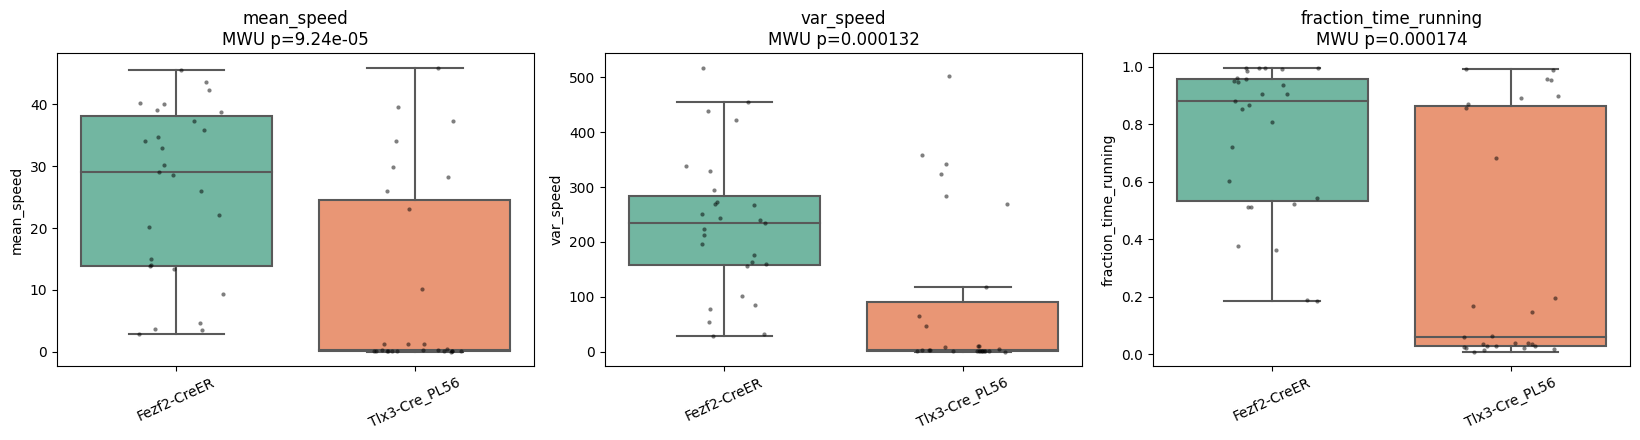

mean_speed                      var_speed                    \
                    mean  median    std count      mean   median      std   
cre_line                                                                    
Fezf2-CreER       25.958  29.004  13.90    27   231.016  233.791  129.537   
Tlx3-Cre_PL56     10.395   0.352  15.59    27    87.468    2.412  148.057   

                    fraction_time_running                      
              count                  mean median    std count  
cre_line                                                       
Fezf2-CreER      27                 0.758  0.882  0.263    27  
Tlx3-Cre_PL56    27                 0.336  0.059  0.412    27


Mann-Whitney U p-values:
              mean_speed: 9.24e-05
               var_speed: 0.000132
   fraction_time_running: 0.000174


In [35]:
# Compare running statistics across the two cre lines
plot_cols = ["mean_speed", "var_speed", "fraction_time_running"]

plot_df = running_stats_df.dropna(subset=["cre_line"]).copy()
cre_lines = sorted(plot_df["cre_line"].unique().tolist())
assert len(cre_lines) == 2, f"Expected exactly 2 cre lines, found {len(cre_lines)}: {cre_lines}"

print("Counts per cre line:")
display(plot_df["cre_line"].value_counts())

fig, axes = plt.subplots(1, len(plot_cols), figsize=(5.5 * len(plot_cols), 4.5))
if len(plot_cols) == 1:
    axes = [axes]

palette = sns.color_palette("Set2", n_colors=2)
pvals = {}
for ax, col in zip(axes, plot_cols):
    sns.boxplot(
        data=plot_df, x="cre_line", y=col, order=cre_lines, ax=ax,
        showfliers=False, palette=palette
    )
    sns.stripplot(
        data=plot_df, x="cre_line", y=col, order=cre_lines, ax=ax,
        color="k", size=3, alpha=0.5, jitter=0.2
    )

    group1 = plot_df.loc[plot_df["cre_line"] == cre_lines[0], col].dropna().values
    group2 = plot_df.loc[plot_df["cre_line"] == cre_lines[1], col].dropna().values
    res = st.mannwhitneyu(group1, group2, alternative="two-sided")
    pvals[col] = res.pvalue

    ax.set_title(f"{col}\nMWU p={res.pvalue:.3g}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

# Compact summary table
summary = (
    plot_df.groupby("cre_line")[plot_cols]
    .agg(["mean", "median", "std", "count"])
    .round(3)
)
display(summary)
print("\nMann-Whitney U p-values:")
for k, v in pvals.items():
    print(f"{k:>24}: {v:.3g}")

In [36]:
## This one dimensional variable of running speed contains a lot of information about the behavior of the animal during the experiment. 
# We can compute various features from this time series, such as mean speed, variance of speed, fraction of time spent running, number of running bouts per minute, average duration of running bouts, etc. 
# We can then compare these features across the two cre lines to see if there are any differences in their running behavior.

def compute_running_features(dataset, speed_threshold_cm_s=2.0, min_bout_duration_s=0.5):
    speed, ts = dataset.get_running_speed()
    valid = np.isfinite(speed) & np.isfinite(ts) & (speed >= -5) & (speed <= 100)
    if valid.sum() < 20:
        return None

    s = speed[valid]
    t = ts[valid]
    dt = float(np.nanmedian(np.diff(t))) if len(t) > 1 else np.nan

    running = s > speed_threshold_cm_s
    frac_running = float(np.mean(running))

    transitions = np.diff(running.astype(int), prepend=0)
    starts = np.where(transitions == 1)[0]
    ends = np.where(transitions == -1)[0] - 1
    if len(running) and running[-1]:
        ends = np.append(ends, len(running) - 1)

    n_pairs = min(len(starts), len(ends))
    starts = starts[:n_pairs]
    ends = ends[:n_pairs]

    n_bouts = n_pairs
    if n_pairs > 0 and np.isfinite(dt):
        bout_durations = (ends - starts + 1) * dt
        keep_bouts = bout_durations >= float(min_bout_duration_s)
        bout_durations = bout_durations[keep_bouts]
        n_bouts = int(keep_bouts.sum())
    else:
        bout_durations = np.array([], dtype=float)

    duration_min = ((t[-1] - t[0]) / 60.0) if len(t) > 1 else np.nan
    bouts_per_min = float(n_bouts / duration_min) if np.isfinite(duration_min) and duration_min > 0 else np.nan
    return {
        "mean_speed": float(np.nanmean(s)),
        "var_speed": float(np.nanvar(s)),
        "max_speed": float(np.nanpercentile(s,99)),
        "frac_running": frac_running,
        "bouts_per_min": bouts_per_min,
        "mean_bout_dur_s": float(np.nanmean(bout_durations)) if len(bout_durations) else 0.0,
        "median_bout_dur_s": float(np.nanmedian(bout_durations)) if len(bout_durations) else 0.0,
        "max_bout_dur_s": float(np.nanmax(bout_durations)) if len(bout_durations) else 0.0
    }

In [37]:
# Build locomotion feature table across all experiments
features_csv = Path("running_features_by_experiment.csv")
use_cached_features = True
min_bout_duration_s = 0.5

if use_cached_features and features_csv.exists():
    running_metrics = pd.read_csv(features_csv)
else:
    rows = []
    for ii, (exp_id, row) in enumerate(experiments_df.iterrows()):
        ds = boc.get_ophys_experiment_data(exp_id)
        feats = compute_running_features(
            ds,
            speed_threshold_cm_s=1.0,
            min_bout_duration_s=min_bout_duration_s,
        )
        if feats is None:
            continue

        feats.update({
            "experiment_id": exp_id,
            "cre_line": row.get("cre_line", None),
            "targeted_structure": row.get("targeted_structure", None),
            "imaging_depth": row.get("imaging_depth", np.nan),
            "session_type": row.get("session_type", None),
        })
        rows.append(feats)

    running_metrics = pd.DataFrame(rows)
    running_metrics.to_csv(features_csv, index=False)
    print(f"Saved features to {features_csv} ({len(running_metrics)} rows)")

running_metrics.head()

,mean_speed,var_speed,max_speed,frac_running,bouts_per_min,mean_bout_dur_s,median_bout_dur_s,max_bout_dur_s,experiment_id,cre_line,targeted_structure,imaging_depth,session_type
0,0.460379,5.123583,13.053224,0.049695,1.574719,1.602164,1.094940,13.40472,566752133,Emx1-IRES-Cre,VISl,175,three_session_C2
1,0.114117,1.159453,5.417812,0.019276,0.612417,1.198069,0.812665,7.19789,653123586,Rorb-IRES2-Cre,VISl,275,three_session_C2
2,1.068383,14.815459,22.108521,0.120625,3.193738,1.692562,0.931000,102.80900,577225417,Vip-IRES-Cre,VISl,275,three_session_C2
3,0.018044,0.314561,1.099192,0.002816,0.062673,0.779730,0.713370,1.09494,556353209,Rbp4-Cre_KL100,VISam,375,three_session_A
4,0.000204,0.525362,1.695781,0.003768,0.000000,0.000000,0.000000,0.00000,510390912,Rorb-IRES2-Cre,VISal,275,three_session_A


In [38]:
## EXERCISE: Using  the running_metrics table, can you identify which features differ across the different cre lines?
# We can try using ANOVA to compute the effect size of each feature across the different cre lines, and then visualize the top features by class. 
# We can also create a heatmap of the z-scored locomotion statistics across classes to see if there are any patterns in the data.
# Estimate feature-wise class effect size (eta^2 from one-way ANOVA decomposition)

def eta_squared_by_group(df, feature_cols, group_col="cre_line", min_per_class=8):
    out = []
    group_counts = df[group_col].value_counts()
    keep = group_counts[group_counts >= min_per_class].index
    sub = df[df[group_col].isin(keep)].copy()

    for feat in feature_cols:
        x = sub[[group_col, feat]].dropna()
        if x.empty or x[group_col].nunique() < 2:
            continue

        grand_mean = x[feat].mean()
        ss_total = ((x[feat] - grand_mean) ** 2).sum()
        if ss_total <= 0:
            continue

        grouped = x.groupby(group_col)[feat]
        means = grouped.mean()
        counts = grouped.size()
        ss_between = ((means - grand_mean) ** 2 * counts).sum()
        eta2 = float(ss_between / ss_total)
        out.append({"feature": feat, "eta2": eta2})

    return pd.DataFrame(out).sort_values("eta2", ascending=False)

metric_cols = [
    "mean_speed", "var_speed", "max_speed", "frac_running", "bouts_per_min",
    "mean_bout_dur_s", "median_bout_dur_s", "max_bout_dur_s",
]
sep_df = eta_squared_by_group(running_metrics, metric_cols, group_col="cre_line", min_per_class=8)
print("Top locomotion features by class effect size (eta^2):")
display(sep_df)



Top locomotion features by class effect size (eta^2):


,feature,eta2
3,frac_running,0.175712
0,mean_speed,0.167328
2,max_speed,0.140803
7,max_bout_dur_s,0.109084
1,var_speed,0.089111
5,mean_bout_dur_s,0.086228
4,bouts_per_min,0.081892
6,median_bout_dur_s,0.045561


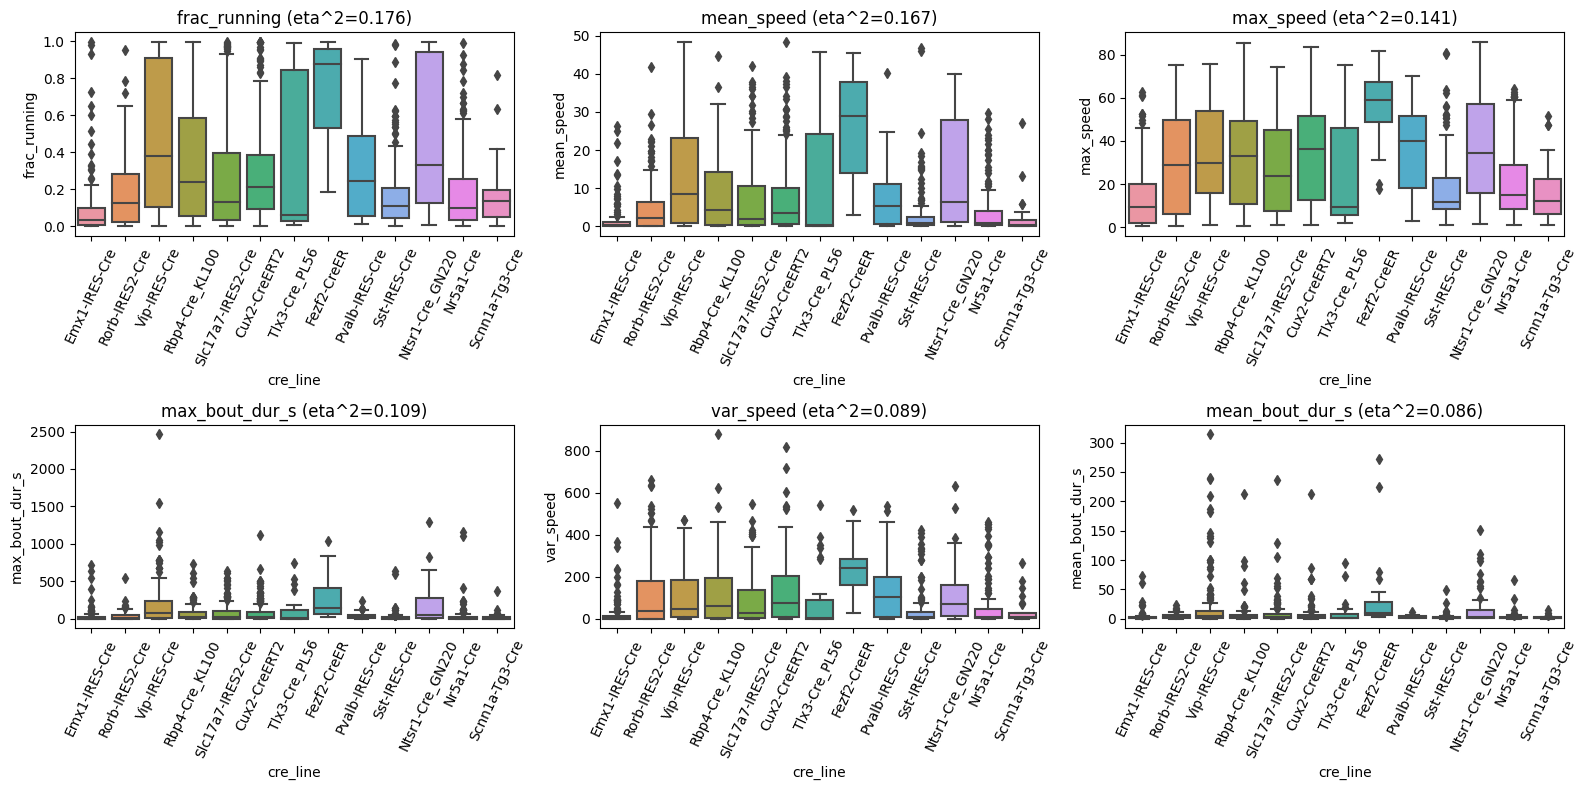

In [39]:
top_feats = sep_df.head(6)["feature"].tolist()
class_counts = running_metrics["cre_line"].value_counts()
keep_labels = class_counts[class_counts >= 8].index.tolist()
viz_df = running_metrics[running_metrics["cre_line"].isin(keep_labels)].copy()

if top_feats:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.ravel()
    for i, feat in enumerate(top_feats):
        sns.boxplot(data=viz_df, x="cre_line", y=feat, ax=axes[i], showfliers=True)
        axes[i].set_title(f"{feat} (eta^2={sep_df.set_index('feature').loc[feat, 'eta2']:.3f})")
        axes[i].tick_params(axis="x", rotation=65)
    for j in range(len(top_feats), 6):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


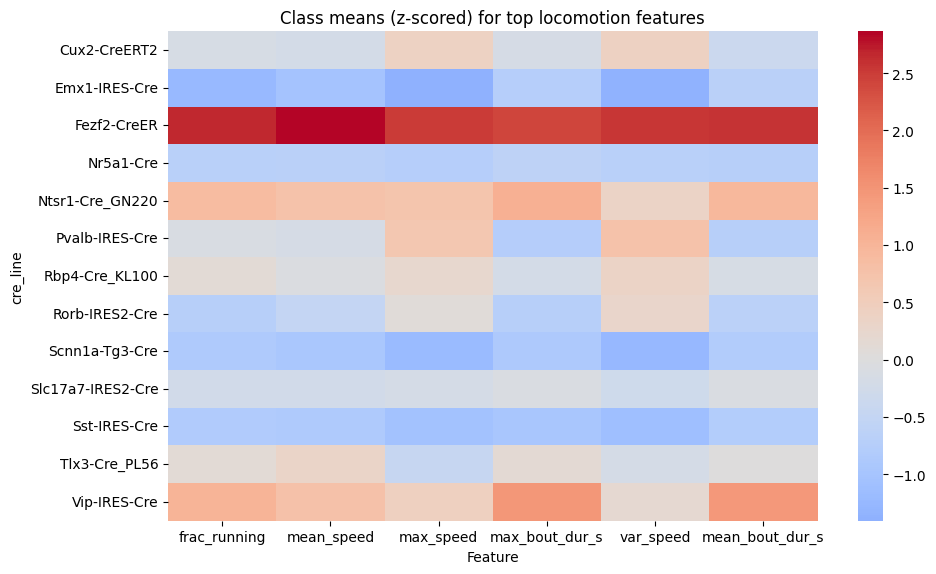

In [40]:
# Class-mean heatmap (z-scored per feature)
mean_table = viz_df.groupby("cre_line")[top_feats].mean()
z_means = (mean_table - mean_table.mean(axis=0)) / mean_table.std(axis=0, ddof=0)
plt.figure(figsize=(10, max(4, 0.45 * len(z_means))))
sns.heatmap(z_means, cmap="coolwarm", center=0, annot=False)
plt.title("Class means (z-scored) for top locomotion features")
plt.xlabel("Feature")
plt.ylabel("cre_line")
plt.tight_layout()
plt.show()
### Pupil features


## 3.1 Can we classify transgenic line using behavioral features?

In [41]:
## 2.1 Are locomotion features linearly separable by transgenic line?
# Basic QC of per-experiment running features
features = [
    "mean_speed", "var_speed", "max_speed", "frac_running", "bouts_per_min",
    "mean_bout_dur_s", "median_bout_dur_s", "max_bout_dur_s",
]

decoder_df = running_metrics.loc[running_metrics.cre_line.isin(cre_lines_of_interest)].dropna(subset=["cre_line"]).copy() #.loc[running_metrics.session_type == 'three_session_A']
decoder_df = decoder_df.replace([np.inf, -np.inf], np.nan)

print(f"Experiments with labels: {len(decoder_df)}")
print("Class counts:")
print(decoder_df["cre_line"].value_counts().head(20))

decoder_df[features].describe().T

Experiments with labels: 714
Class counts:
Cux2-CreERT2       228
Rorb-IRES2-Cre     120
Nr5a1-Cre          117
Rbp4-Cre_KL100     114
Ntsr1-Cre_GN220     54
Tlx3-Cre_PL56       27
Fezf2-CreER         27
Scnn1a-Tg3-Cre      27
Name: cre_line, dtype: int64


,count,mean,std,min,25%,50%,75%,max
mean_speed,714.0,7.506303,10.484498,-0.056959,0.364841,2.395359,10.742152,48.512970
var_speed,714.0,112.578183,146.352902,0.020784,4.749134,39.999429,182.326346,879.143746
max_speed,714.0,30.799388,22.567478,0.344710,10.296356,27.956402,50.404902,86.162849
frac_running,714.0,0.291555,0.294375,0.000009,0.058499,0.179196,0.429882,0.998311
bouts_per_min,714.0,2.744223,2.350256,0.000000,0.949250,2.323399,3.859990,13.144265
mean_bout_dur_s,714.0,8.137823,22.253582,0.000000,1.353567,3.148738,6.100664,272.733125
median_bout_dur_s,714.0,3.677910,11.813748,0.000000,0.962873,1.610928,2.720714,184.055375
max_bout_dur_s,714.0,82.951712,156.563929,0.000000,6.335955,23.400020,83.852848,1289.202250


Using 5-fold stratified CV (smallest class = 27)

Fold accuracies: [0.217 0.245 0.252 0.252 0.197]
Mean accuracy:   0.232 +/- 0.022
Chance (1/n_classes): 0.125

Classification report (out-of-fold):
                 precision    recall  f1-score   support

   Cux2-CreERT2       0.48      0.18      0.26       228
    Fezf2-CreER       0.13      0.52      0.21        27
      Nr5a1-Cre       0.33      0.39      0.36       117
Ntsr1-Cre_GN220       0.04      0.02      0.03        54
 Rbp4-Cre_KL100       0.16      0.04      0.06       114
 Rorb-IRES2-Cre       0.34      0.38      0.36       120
 Scnn1a-Tg3-Cre       0.09      0.41      0.14        27
  Tlx3-Cre_PL56       0.05      0.15      0.08        27

       accuracy                           0.23       714
      macro avg       0.20      0.26      0.19       714
   weighted avg       0.30      0.23      0.23       714



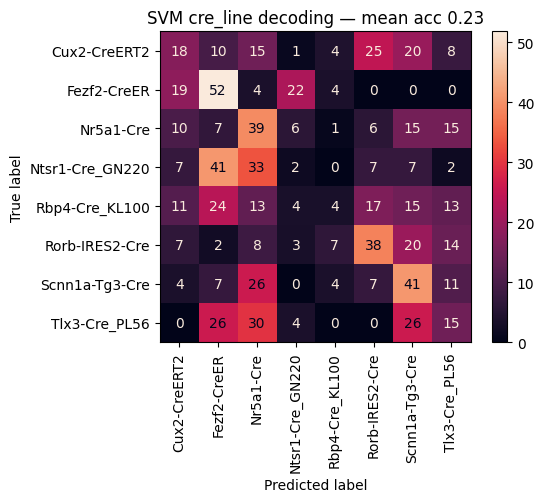

In [42]:
target = 'cre_line'
X = decoder_df[features].to_numpy()
y = decoder_df[target].to_numpy()

# Stratified k-fold CV 
# n_splits cannot exceed the smallest class size
min_class = decoder_df[target].value_counts().min()
n_splits = int(min(5, min_class))
print(f"Using {n_splits}-fold stratified CV (smallest class = {min_class})")
n_classes = np.unique(y).size

#Define a simple pipeline that scales the features and then applies LDA for classification
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('SVM (linear)', SVC(kernel='linear', class_weight='balanced')),
    # ('LogReg', LogisticRegression(max_iter=5000, class_weight='balanced')),
])

# Create the StratifiedKFold object and compute cross-validated accuracy scores
skf = StratifiedKFold(n_splits=n_splits)

# Feed these objects into the cross_val_score function to get out-of-fold accuracy scores for each fold, 
# and then compute the mean and standard deviation of these scores across folds to get an estimate of how well our classifier is performing on unseen data.
cv_scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
print(f"\nFold accuracies: {np.round(cv_scores, 3)}")
print(f"Mean accuracy:   {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print(f"Chance (1/n_classes): {1.0 / np.unique(y).size:.3f}")

# Out-of-fold predictions for a confusion matrix / classification report
y_pred = cross_val_predict(pipe, X, y, cv=skf)
print("\nClassification report (out-of-fold):")
print(classification_report(y, y_pred, zero_division=0))

labels = np.unique(y)
cm = confusion_matrix(y, y_pred, labels=labels, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm*100, display_labels=labels).plot(ax=ax, cmap='rocket',include_values=True,values_format='.0f',
                                                       xticks_rotation=90, colorbar=True)
ax.set_title(f"SVM cre_line decoding — mean acc {cv_scores.mean():.2f}")
plt.tight_layout()
plt.show()


In [43]:
## Woah, so the decoding isn't as good as it was with the neural features, but still above chance! This suggests that there are some differences in the running behavior
#  of the different transgenic lines, but it's not as strongly predictive as the neural response features we looked at before. Can you think of any reasons why this might be the case?
# Which cre lines are most confusable based on the confusion matrix? Do these lines have similar running behavior based on the feature distributions we looked at before?
#
## MORE PROJECT IDEAS:
# 1) Can we combine the neural response features and the running behavior features to improve decoding accuracy?
# -> -> This is a bit tricky because the neural features were calculated on experiment-id level (multiple experiments) whereas the running features were calculated on a per-experiment level. 
# -> -> We would have to decide how to combine these features in a meaningful way, perhaps by averaging the neural features across experiments for each cre line.
# 2) Can we look at more neural features across different stimulus types (e.g. static gratings, natural movies, etc) and see if we can improve decoding accuracy by combining features across stimulus types?